In [1]:
import pandas as pd
import os
from glob import glob
from sklearn.metrics import precision_recall_curve, auc
from sklearn.calibration import calibration_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
def compute_auprc(group):
    y_true = group['labels'] if 'labels' in group else group['label']
    y_scores = group['predicted_ions'] if 'predicted_ions' in group else group['predicted']
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    return auc(recall, precision)

# Metal ions

In [3]:
AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']

model_results = []
for metal_ion in AF3_metal_ions:
    no_pretrain = glob(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/models/{metal_ion}/no_pretrain_test_results_*.csv")
    with_pretrain = glob(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/models/{metal_ion}/with_pretrain_test_results_*.csv")
    assert len(no_pretrain) == 3, f"Expected 3 no_pretrain files for {metal_ion}, got {len(no_pretrain)}"
    assert len(with_pretrain) == 3, f"Expected 3 with_pretrain files for {metal_ion}, got {len(with_pretrain)}"
    for fname in no_pretrain:
        df = pd.read_csv(fname)
        df['metal_ion'] = metal_ion
        df['replicate'] = os.path.basename(fname).split('_')[-1].split('.')[0]
        df['pretrain'] = False
        model_results.append(df)
    for fname in with_pretrain:
        df = pd.read_csv(fname)
        df['metal_ion'] = metal_ion
        df['replicate'] = os.path.basename(fname).split('_')[-1].split('.')[0]
        df['pretrain'] = True
        model_results.append(df)
model_results = pd.concat(model_results)

auprc_results = model_results.groupby(['pretrain', 'metal_ion', 'replicate']).apply(compute_auprc)
auprc_results_df = auprc_results.reset_index(name='AUPRC')
auprc_results_df = auprc_results_df.groupby(['pretrain', 'metal_ion'])['AUPRC'].agg(['mean', 'std']).reset_index()

baseline_results = model_results.groupby(['metal_ion'])['labels'].agg(['mean']).reset_index()
baseline_results['model'] = 'reference'
baseline_results['std'] = 0
auprc_results_df.rename(columns={'pretrain': 'model'}, inplace=True)
auprc_results_df['model'] = auprc_results_df['model'].replace({True: 'pretrain', False: 'no_pretrain'})
auprc_results_df = pd.concat([baseline_results, auprc_results_df])

/tmp/ipykernel_3645732/1467183640.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auprc_results = model_results.groupby(['pretrain', 'metal_ion', 'replicate']).apply(compute_auprc)


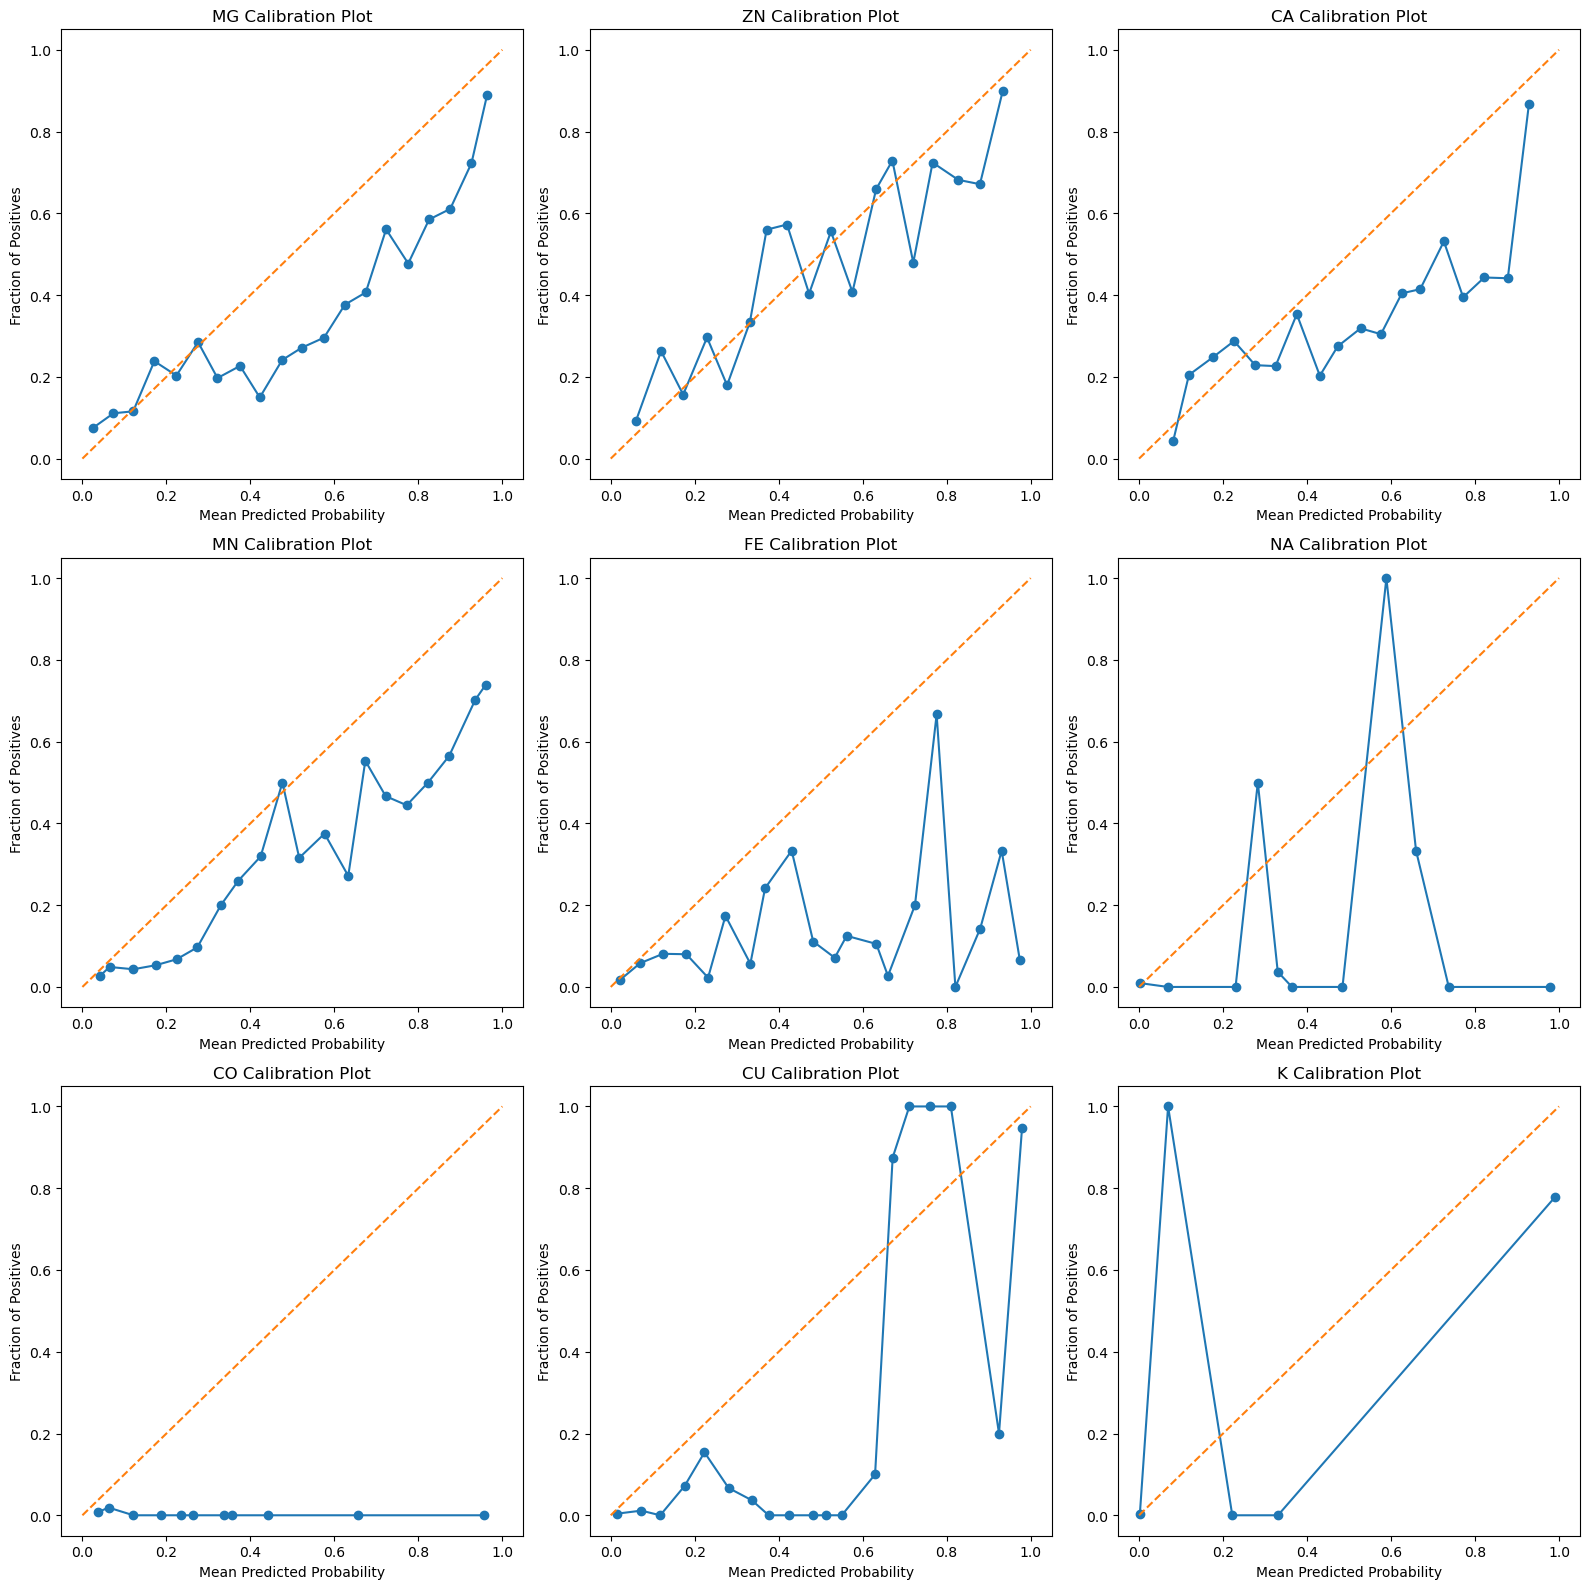

In [4]:
mean_prediction = model_results[model_results['pretrain']].groupby(['metal_ion', 'ids'])[['predicted_ions', 'labels']].mean().reset_index()

fig, ax = plt.subplots(3, 3, figsize=(16, 16))

for idx, metal_ion in enumerate(AF3_metal_ions):
    pred_probs = mean_prediction[mean_prediction['metal_ion']==metal_ion]['predicted_ions']
    y_test = mean_prediction[mean_prediction['metal_ion']==metal_ion]['labels']
    prob_true, prob_pred = calibration_curve(y_test, pred_probs, n_bins=20, strategy='uniform')
    
    row_idx = idx // 3
    col_idx = idx % 3

    ax[row_idx, col_idx].plot(prob_pred, prob_true, marker='o', label=metal_ion)
    ax[row_idx, col_idx].plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
    ax[row_idx, col_idx].set_title(f'{metal_ion} Calibration Plot')
    ax[row_idx, col_idx].set_xlabel('Mean Predicted Probability')
    ax[row_idx, col_idx].set_ylabel('Fraction of Positives')

plt.tight_layout()
plt.show()

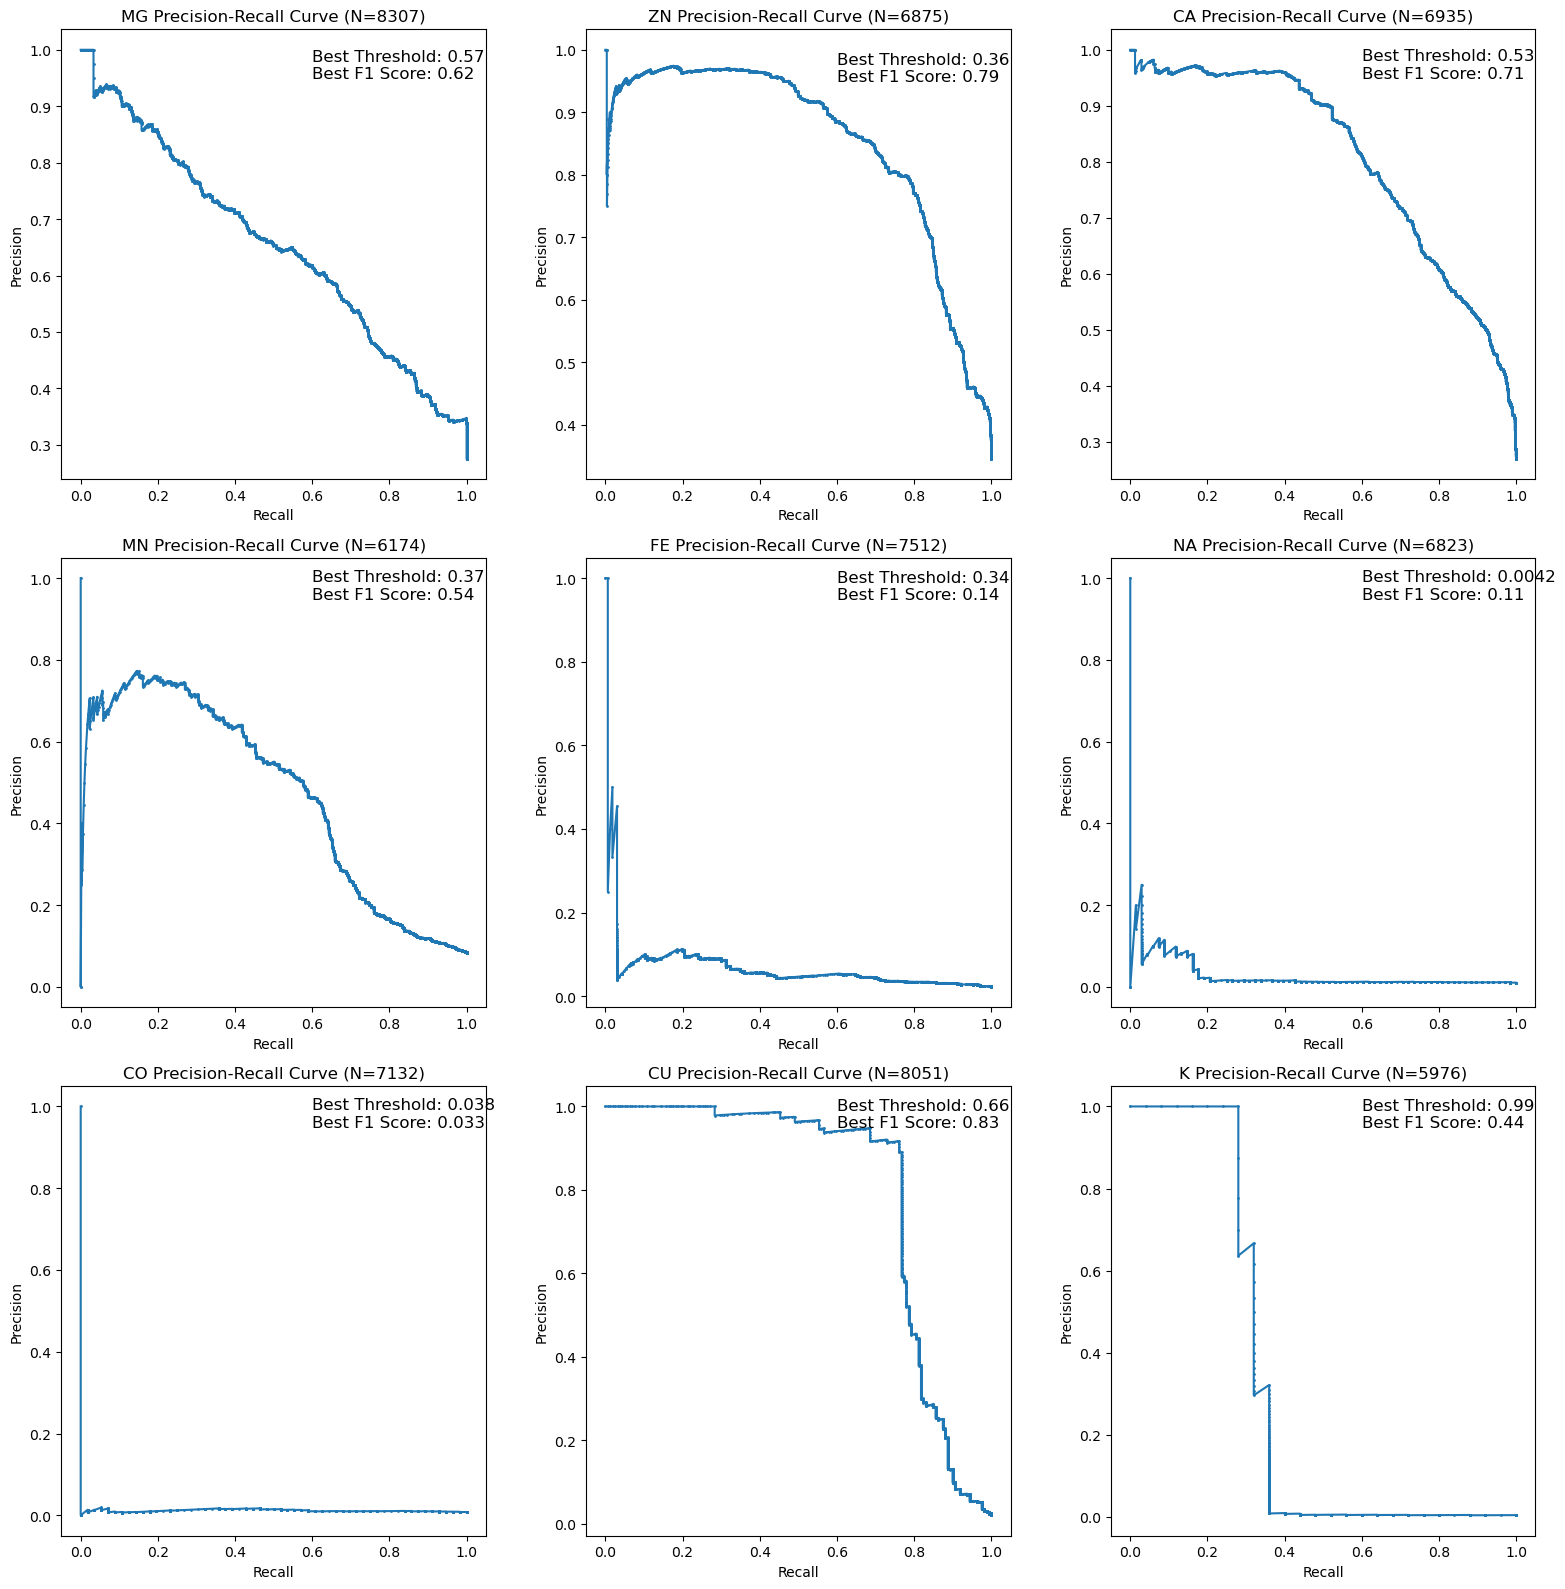

In [5]:
ion_thresholds = []
mean_prediction = model_results[model_results['pretrain']].groupby(['metal_ion', 'ids'])[['predicted_ions', 'labels']].mean().reset_index()

fig, ax = plt.subplots(3, 3, figsize=(16, 16))

for idx, metal_ion in enumerate(AF3_metal_ions):
    pred_probs = mean_prediction[mean_prediction['metal_ion']==metal_ion]['predicted_ions']
    y_test = mean_prediction[mean_prediction['metal_ion']==metal_ion]['labels']

    precision, recall, thresholds = precision_recall_curve(y_test, pred_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
    f1_scores = f1_scores[:-1] 

    best_threshold_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_threshold_idx]
    best_f1_score = f1_scores[best_threshold_idx]

    ion_thresholds.append({
        'metal_ion': metal_ion,
        'best_threshold': best_threshold,
        'best_f1_score': best_f1_score
    })
    
    row_idx = idx // 3
    col_idx = idx % 3

    ax[row_idx, col_idx].plot(recall, precision, marker='o', label=metal_ion, markersize=1)
    ax[row_idx, col_idx].set_title(f'{metal_ion} Precision-Recall Curve (N={len(y_test)})')
    ax[row_idx, col_idx].set_xlabel('Recall')
    ax[row_idx, col_idx].set_ylabel('Precision')
    ax[row_idx, col_idx].text(0.6, 0.95, f'Best Threshold: {best_threshold:.2g}\nBest F1 Score: {best_f1_score:.2g}', fontsize=12)

ion_thresholds_df = pd.DataFrame(ion_thresholds)

plt.tight_layout()
plt.show()

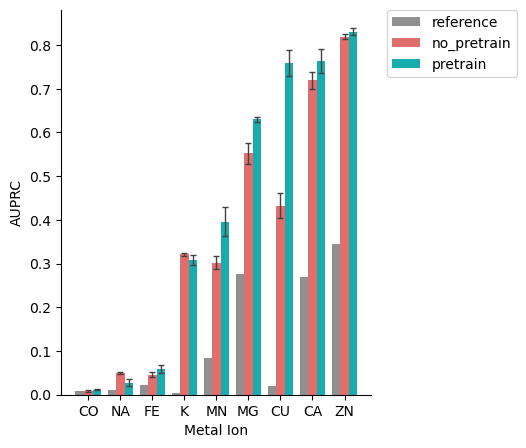

In [6]:
plt.figure(figsize=(4,5))

sorted_order = auprc_results_df[auprc_results_df['model']=='pretrain'].sort_values(by='mean')['metal_ion'].tolist()
sns_plot = sns.barplot(
    x='metal_ion', 
    y='mean', 
    hue='model', 
    data=auprc_results_df, 
    order=sorted_order,
    palette=['#909090', '#F55959', '#00C4C7']
)

models = auprc_results_df['model'].unique()
n_models = len(models)
bar_width = sns_plot.patches[0].get_width()
for i, model in enumerate(models):
    if model == 'reference':
        continue
    model_data = auprc_results_df[auprc_results_df['model'] == model]
    model_data = model_data.set_index('metal_ion').loc[sorted_order].reset_index()
    offset = (i - (n_models - 1) / 2) * bar_width
    line_color = sns_plot.get_lines()[i].get_color()
    plt.errorbar(
        x=np.arange(len(model_data['metal_ion'])) + offset, 
        y=model_data['mean'], 
        yerr=model_data['std'], 
        fmt='none', 
        capsize=2, 
        elinewidth=1, 
        color=line_color
    )

sns.despine()
plt.xlabel('Metal Ion')
plt.ylabel('AUPRC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., prop={'size': 10})
plt.show()

In [7]:
ion_thresholds_df['best_threshold_min_cutoff'] = ion_thresholds_df['best_threshold'].apply(lambda x: np.clip(x, 0.05, 0.95))
ion_thresholds_df

,metal_ion,best_threshold,best_f1_score,best_threshold_min_cutoff
0,MG,0.574790,0.621128,0.574790
1,ZN,0.361554,0.790924,0.361554
2,CA,0.530423,0.711377,0.530423
3,MN,0.371361,0.538248,0.371361
4,FE,0.341234,0.144067,0.341234
5,NA,0.004228,0.110497,0.050000
6,CO,0.037873,0.032766,0.050000
7,CU,0.662588,0.831615,0.662588
8,K,0.992039,0.437500,0.950000


In [8]:
ion_thresholds_dict = dict(zip(ion_thresholds_df['metal_ion'], ion_thresholds_df['best_threshold_min_cutoff']))

dark_proteome_ion_results = []
for metal_ion in AF3_metal_ions:
    dark_proteome_files = glob(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/models/{metal_ion}/dark_proteome_version_*.csv")
    assert len(dark_proteome_files) == 3, f"Expected 3 dark_proteome files for {metal_ion}, got {len(dark_proteome_files)}"
    for fname in dark_proteome_files:
        df = pd.read_csv(fname)
        df['metal_ion'] = metal_ion
        df['version'] = os.path.basename(fname).split('_')[-1].split('.')[0]
        dark_proteome_ion_results.append(df)
dark_proteome_ion_results = pd.concat(dark_proteome_ion_results)
dark_proteome_ion_results.drop(columns=['label'], inplace=True)
dark_proteome_ion_results = dark_proteome_ion_results.groupby(['metal_ion', 'id'])[['predicted']].agg(['mean', 'std']).reset_index()
dark_proteome_ion_results.columns = ['metal_ion', 'id', 'mean', 'std']
dark_proteome_ion_results['prediction'] = dark_proteome_ion_results.apply(lambda row: row['mean'] > ion_thresholds_dict[row['metal_ion']], axis=1)
dark_proteome_ion_results.groupby(['metal_ion'])['prediction'].agg(['sum', 'count'])

,sum,count
metal_ion,,
CA,280,2851
CO,30,2851
CU,11,2851
FE,277,2851
K,0,2851
MG,406,2851
MN,51,2851
NA,3,2851
ZN,1922,2851


In [9]:
dark_proteome_ion_results[dark_proteome_ion_results['prediction']]['id'].unique().shape[0]

2565

# Ligands

In [10]:
ligands = ["ADP","ATP","GTP","GDP","FAD","NAD","NAP","NDP","HEM","HEC","CIT","CLA"]

model_results = []
for small_molecule in ligands:
    no_pretrain = glob(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/models/{small_molecule}/no_pretrain_test_results_*.csv")
    with_pretrain = glob(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/models/{small_molecule}/with_pretrain_test_results_*.csv")
    assert len(no_pretrain) == 3, f"Expected 3 no_pretrain files for {small_molecule}, got {len(no_pretrain)}"
    assert len(with_pretrain) == 3, f"Expected 3 with_pretrain files for {small_molecule}, got {len(with_pretrain)}"
    for fname in no_pretrain:
        df = pd.read_csv(fname)
        df['small_molecule'] = small_molecule
        df['replicate'] = os.path.basename(fname).split('_')[-1].split('.')[0]
        df['pretrain'] = False
        model_results.append(df)
    for fname in with_pretrain:
        df = pd.read_csv(fname)
        df['small_molecule'] = small_molecule
        df['replicate'] = os.path.basename(fname).split('_')[-1].split('.')[0]
        df['pretrain'] = True
        model_results.append(df)
model_results = pd.concat(model_results)

auprc_results = model_results.groupby(['pretrain', 'small_molecule', 'replicate']).apply(compute_auprc)
auprc_results_df = auprc_results.reset_index(name='AUPRC')
auprc_results_df = auprc_results_df.groupby(['pretrain', 'small_molecule'])['AUPRC'].agg(['mean', 'std']).reset_index()

baseline_results = model_results.groupby(['small_molecule'])['label'].agg(['mean']).reset_index()
baseline_results['model'] = 'reference'
baseline_results['std'] = 0
auprc_results_df.rename(columns={'pretrain': 'model'}, inplace=True)
auprc_results_df['model'] = auprc_results_df['model'].replace({True: 'pretrain', False: 'no_pretrain'})
auprc_results_df = pd.concat([baseline_results, auprc_results_df])

/tmp/ipykernel_3645732/3031546823.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auprc_results = model_results.groupby(['pretrain', 'small_molecule', 'replicate']).apply(compute_auprc)


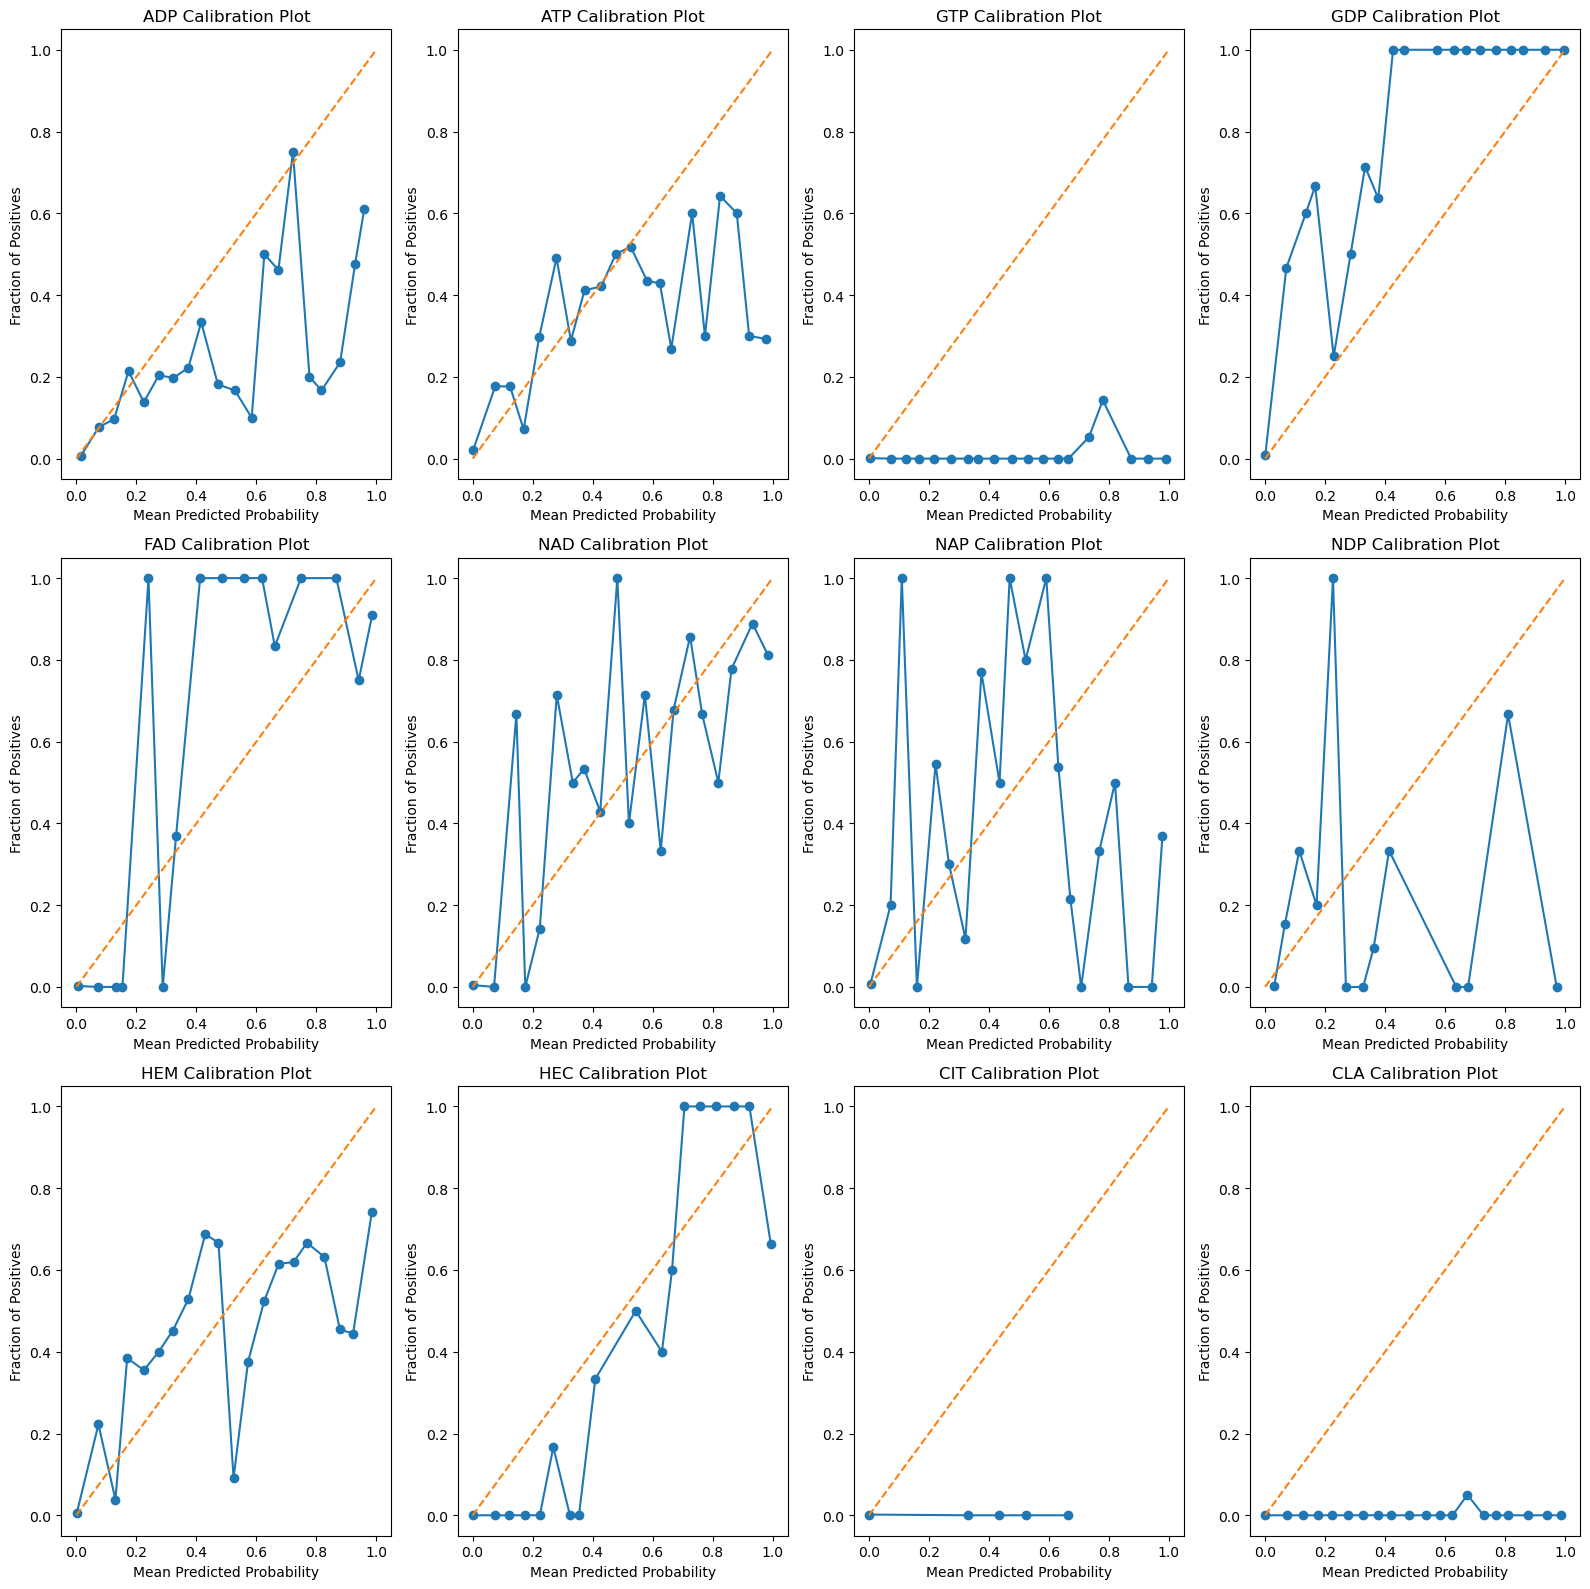

In [11]:
mean_prediction = model_results[model_results['pretrain']].groupby(['small_molecule', 'id'])[['predicted', 'label']].mean().reset_index()

fig, ax = plt.subplots(3, 4, figsize=(16, 16))

for idx, small_molecule in enumerate(ligands):
    pred_probs = mean_prediction[mean_prediction['small_molecule']==small_molecule]['predicted']
    y_test = mean_prediction[mean_prediction['small_molecule']==small_molecule]['label']
    prob_true, prob_pred = calibration_curve(y_test, pred_probs, n_bins=20, strategy='uniform')
    
    row_idx = idx // 4
    col_idx = idx % 4

    ax[row_idx, col_idx].plot(prob_pred, prob_true, marker='o', label=small_molecule)
    ax[row_idx, col_idx].plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
    ax[row_idx, col_idx].set_title(f'{small_molecule} Calibration Plot')
    ax[row_idx, col_idx].set_xlabel('Mean Predicted Probability')
    ax[row_idx, col_idx].set_ylabel('Fraction of Positives')

plt.tight_layout()
plt.show()

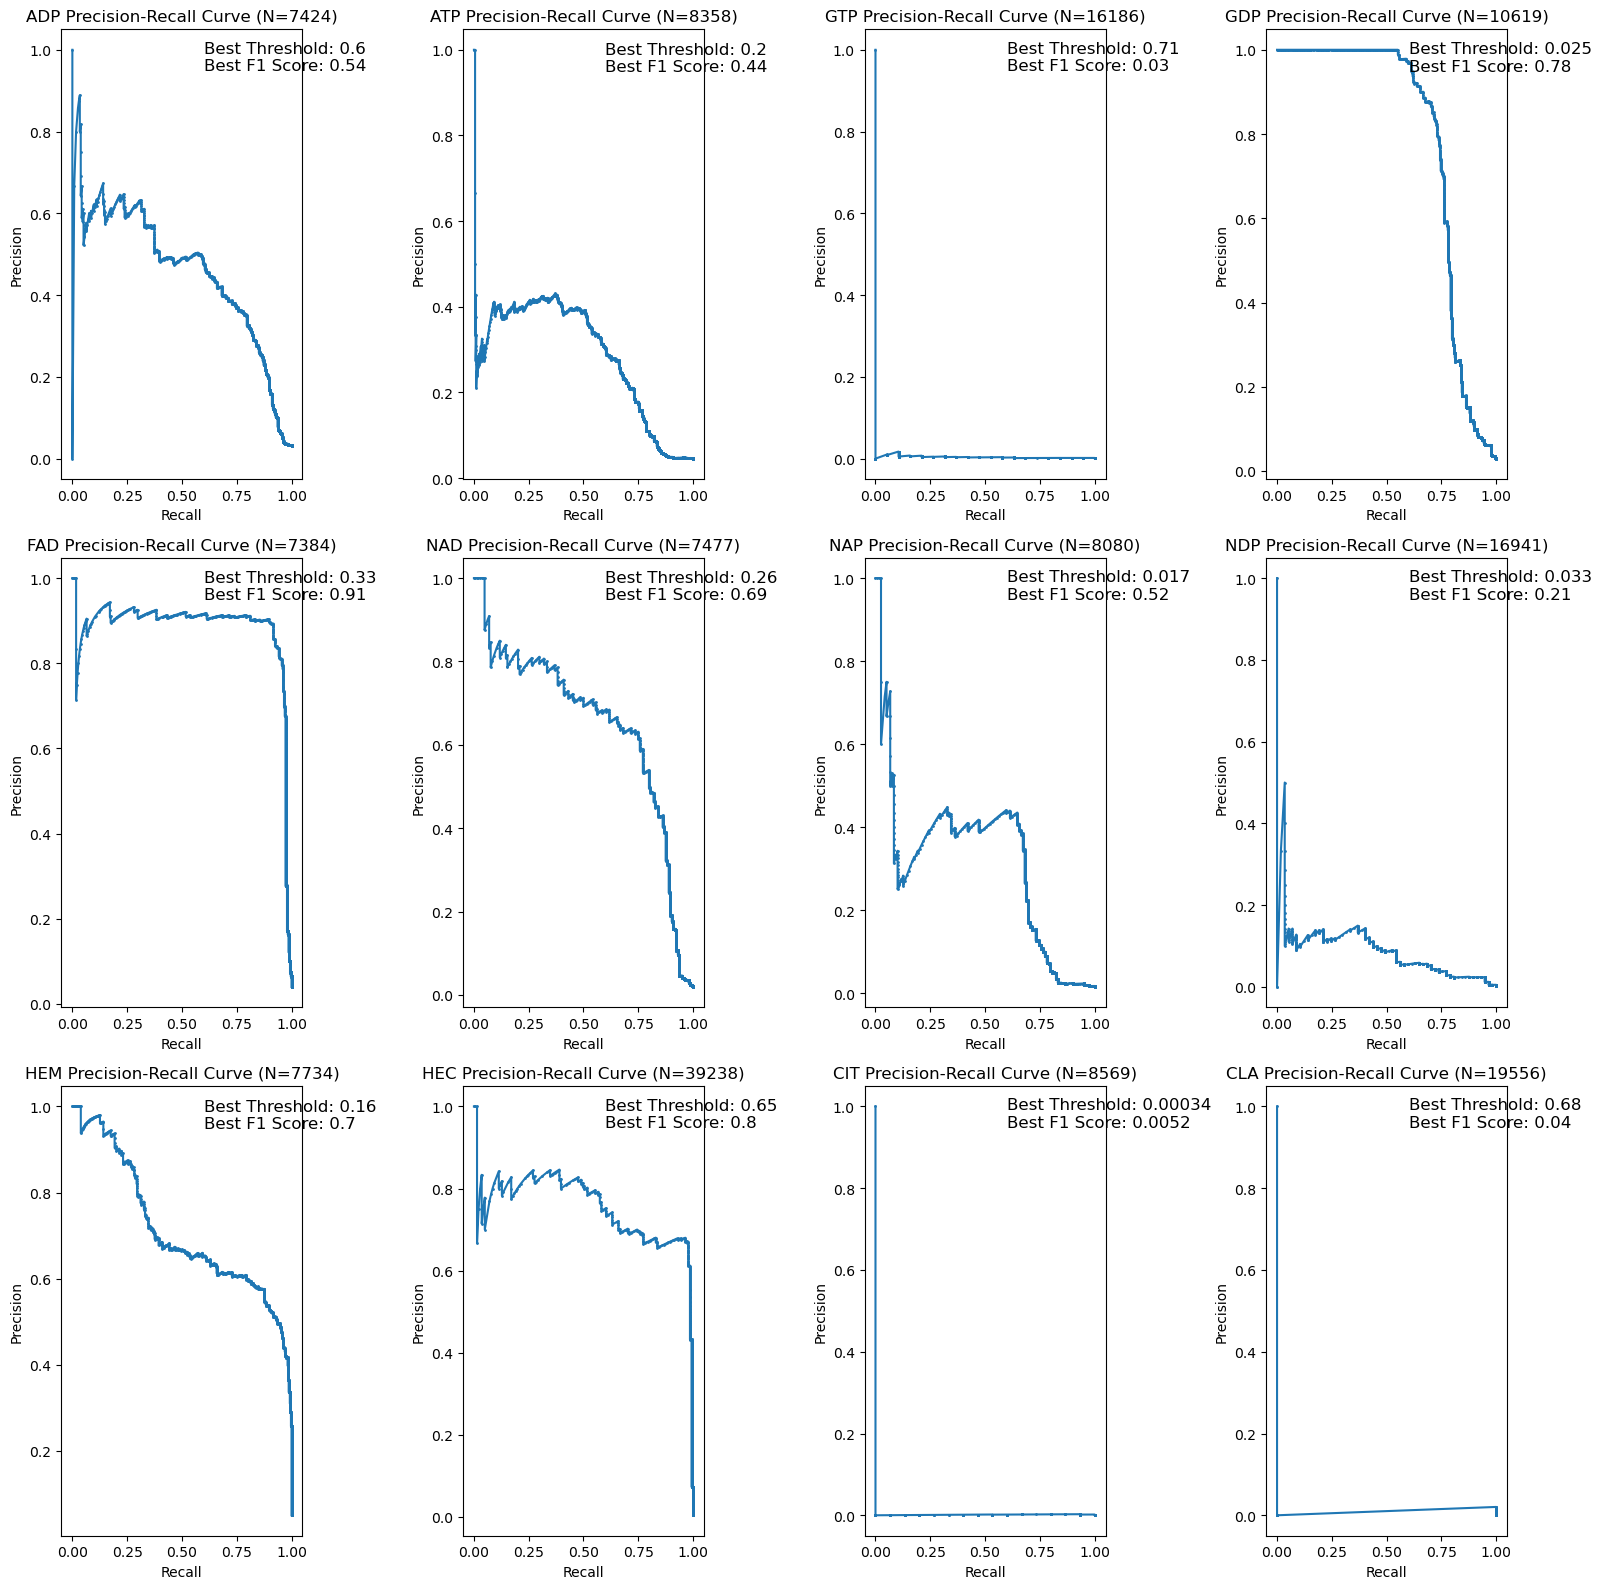

In [12]:
small_molecule_thresholds = []
mean_prediction = model_results[model_results['pretrain']].groupby(['small_molecule', 'id'])[['predicted', 'label']].mean().reset_index()

fig, ax = plt.subplots(3, 4, figsize=(16, 16))

for idx, small_molecule in enumerate(ligands):
    pred_probs = mean_prediction[mean_prediction['small_molecule']==small_molecule]['predicted']
    y_test = mean_prediction[mean_prediction['small_molecule']==small_molecule]['label']

    precision, recall, thresholds = precision_recall_curve(y_test, pred_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
    f1_scores = f1_scores[:-1] 

    best_threshold_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_threshold_idx]
    best_f1_score = f1_scores[best_threshold_idx]

    small_molecule_thresholds.append({
        'small_molecule': small_molecule,
        'best_threshold': best_threshold,
        'best_f1_score': best_f1_score
    })
    
    row_idx = idx // 4
    col_idx = idx % 4

    ax[row_idx, col_idx].plot(recall, precision, marker='o', label=small_molecule, markersize=1)
    ax[row_idx, col_idx].set_title(f'{small_molecule} Precision-Recall Curve (N={len(y_test)})')
    ax[row_idx, col_idx].set_xlabel('Recall')
    ax[row_idx, col_idx].set_ylabel('Precision')
    ax[row_idx, col_idx].text(0.6, 0.95, f'Best Threshold: {best_threshold:.2g}\nBest F1 Score: {best_f1_score:.2g}', fontsize=12)

small_molecule_thresholds_df = pd.DataFrame(small_molecule_thresholds)

plt.tight_layout()
plt.show()

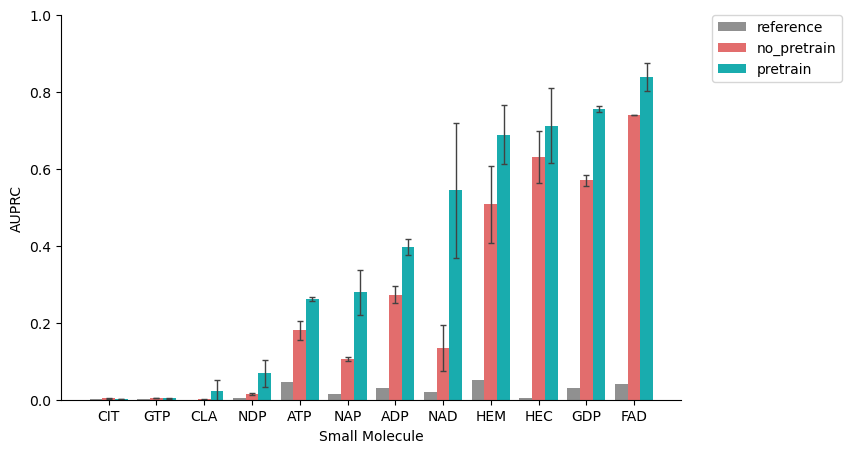

In [13]:
plt.figure(figsize=(8,5))

sorted_order = auprc_results_df[auprc_results_df['model']=='pretrain'].sort_values(by='mean')['small_molecule'].tolist()
sns_plot = sns.barplot(
    x='small_molecule', 
    y='mean', 
    hue='model', 
    data=auprc_results_df, 
    order=sorted_order,
    palette=['#909090', '#F55959', '#00C4C7']
)

models = auprc_results_df['model'].unique()
n_models = len(models)
bar_width = sns_plot.patches[0].get_width()
for i, model in enumerate(models):
    if model == 'reference':
        continue
    model_data = auprc_results_df[auprc_results_df['model'] == model]
    model_data = model_data.set_index('small_molecule').loc[sorted_order].reset_index()
    offset = (i - (n_models - 1) / 2) * bar_width
    line_color = sns_plot.get_lines()[i].get_color()
    plt.errorbar(
        x=np.arange(len(model_data['small_molecule'])) + offset, 
        y=model_data['mean'], 
        yerr=model_data['std'], 
        fmt='none', 
        capsize=2, 
        elinewidth=1, 
        color=line_color
    )

sns.despine()
plt.xlabel('Small Molecule')
plt.ylim(0,1)
plt.ylabel('AUPRC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., prop={'size': 10})
plt.show()

In [14]:
small_molecule_thresholds_df['best_threshold_min_cutoff'] = small_molecule_thresholds_df['best_threshold'].apply(lambda x: np.clip(x, 0.05, 0.95))
small_molecule_thresholds_df

,small_molecule,best_threshold,best_f1_score,best_threshold_min_cutoff
0,ADP,0.603588,0.540117,0.603588
1,ATP,0.203433,0.442660,0.203433
2,GTP,0.714321,0.029629,0.714321
3,GDP,0.025051,0.779359,0.050000
4,FAD,0.332102,0.905405,0.332102
5,NAD,0.256138,0.685714,0.256138
6,NAP,0.017136,0.520270,0.050000
7,NDP,0.032700,0.213198,0.050000
8,HEM,0.159546,0.695208,0.159546
9,HEC,0.647787,0.797653,0.647787


In [15]:
small_molecule_thresholds_dict = dict(zip(small_molecule_thresholds_df['small_molecule'], small_molecule_thresholds_df['best_threshold_min_cutoff']))

dark_proteome_small_molecule_results = []
for small_molecule in ligands:
    dark_proteome_files = glob(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/models/{small_molecule}/dark_proteome_version_*.csv")
    assert len(dark_proteome_files) == 3, f"Expected 3 dark_proteome files for {small_molecule}, got {len(dark_proteome_files)}"
    for fname in dark_proteome_files:
        df = pd.read_csv(fname)
        df['small_molecule'] = small_molecule
        df['version'] = os.path.basename(fname).split('_')[-1].split('.')[0]
        dark_proteome_small_molecule_results.append(df)
dark_proteome_small_molecule_results = pd.concat(dark_proteome_small_molecule_results)
dark_proteome_small_molecule_results.drop(columns=['label'], inplace=True)
dark_proteome_small_molecule_results = dark_proteome_small_molecule_results.groupby(['small_molecule', 'id'])[['predicted']].agg(['mean', 'std']).reset_index()
dark_proteome_small_molecule_results.columns = ['small_molecule', 'id', 'mean', 'std']
dark_proteome_small_molecule_results['prediction'] = dark_proteome_small_molecule_results.apply(lambda row: row['mean'] > small_molecule_thresholds_dict[row['small_molecule']], axis=1)
dark_proteome_small_molecule_results.groupby(['small_molecule'])['prediction'].agg(['sum', 'count'])

,sum,count
small_molecule,,
ADP,3,969
ATP,5,969
CIT,1,969
CLA,0,969
FAD,1,969
GDP,1,969
GTP,0,969
HEC,8,969
HEM,59,969


In [16]:
dark_proteome_small_molecule_results[dark_proteome_small_molecule_results['prediction']]['id'].unique().shape[0]

81

### Save results

In [17]:
thresholds = pd.concat([
    small_molecule_thresholds_df[['small_molecule', 'best_threshold_min_cutoff']].rename(columns={'best_threshold_min_cutoff': 'best_threshold', 'small_molecule': 'ligand'}),
    ion_thresholds_df[['metal_ion', 'best_threshold_min_cutoff']].rename(columns={'best_threshold_min_cutoff': 'best_threshold', 'metal_ion': 'ligand'})
]).sort_values(by='ligand').set_index('ligand').to_dict()['best_threshold']

import json
with open('ATOMICA_ligand_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=4)

In [18]:
ion_annotated_ids = dark_proteome_ion_results[dark_proteome_ion_results['prediction']]['id'].unique().tolist()
sm_annotated_ids = dark_proteome_small_molecule_results[dark_proteome_small_molecule_results['prediction']]['id'].unique().tolist()
print(f"Number of annotated proteins for metal ions: {len(ion_annotated_ids)}")
print(f"Number of annotated proteins for small molecules: {len(sm_annotated_ids)}")
print(f"Union of annotated proteins: {len(set(ion_annotated_ids + sm_annotated_ids))}")
print(f"Intersection of annotated proteins: {len(set(ion_annotated_ids) & set(sm_annotated_ids))}")

Number of annotated proteins for metal ions: 2565
Number of annotated proteins for small molecules: 81
Union of annotated proteins: 2642
Intersection of annotated proteins: 4


In [19]:
final_results = pd.concat([
    dark_proteome_ion_results.rename(columns={'metal_ion': 'ligand'}),
    dark_proteome_small_molecule_results.rename(columns={'small_molecule': 'ligand'}),
])

final_results[final_results['prediction']][['ligand', 'id', 'mean', 'std']].to_csv('dark_proteome_predictions.csv', index=False)

# for pasting in latex
# for _, row in final_results[final_results['prediction']].groupby('ligand').agg({'id': list}).reset_index().iterrows():
#     print(f"{row['ligand']} & {len(row['id'])} & {', '.join(row['id'])} \\\\")

# Prepare AF3 for the annotated dark proteome

In [20]:
# for any missing fastas rewrite them
from Bio import PDB
from Bio.SeqUtils import seq1
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import json

def pdb_to_fasta(pdb_filename):
    structure_id = os.path.basename(pdb_filename).split('.')[0]

    # Create a PDB parser
    parser = PDB.PDBParser(QUIET=True)

    # Parse the structure
    structure = parser.get_structure("protein_structure", pdb_filename)

    output = {}

    # Open the FASTA file for writing
    for model in structure:
        for chain in model:
            sequence = ""
            for residue in chain:
                # Ensure the residue is an amino acid
                if PDB.is_aa(residue, standard=True):
                    sequence += seq1(residue.get_resname())
            
            # Create a sequence record for the chain
            seq_record = SeqRecord(
                Seq(sequence),
                id=f"{structure_id}_{chain.id}",
                description=f"Chain {chain.id}"
            )

            output[seq_record.id] = str(seq_record.seq)
    return output

def write_AF3_json(item_id, fasta_str, ligand, output_path):
    if ligand == 'HEC':
        smiles = 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C'
        item_job = {
            "name": f'{item_id}_{ligand}',
            "modelSeeds": [1],
            "sequences": [
                {"protein": {"id": 'A', "sequence": fasta_str}},
                {"ligand": {"id": 'B', "smiles": smiles}},
            ],
            "dialect": "alphafold3",
            "version": 1
        }
    else:
        item_job = {
            "name": f'{item_id}_{ligand}',
            "modelSeeds": [1],
            "sequences": [
                {"protein": {"id": 'A', "sequence": fasta_str}},
                {"ligand": {"id": ['B'], "ccdCodes": [ligand]}},
            ],
            "dialect": "alphafold3",
            "version": 1
        }
    with open(output_path, 'w') as f:
        json.dump(item_job, f, indent=2)

In [21]:
existing_results = glob("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/analyses/updated_model/outputs/**/*") + glob("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/analyses/updated_reference/outputs/**/*")
existing_results_df = []
for fname in existing_results:
    if 'updated_reference/outputs/old/' in fname:
        continue # cannot trust these results
    prot_id = os.path.basename(fname).split("_")[0].upper()
    ligand = os.path.basename(fname).split("_")[1].upper()
    existing_results_df.append({
        'ligand': ligand,
        'prot_id': prot_id,
        'results_path': fname
    })
existing_results_df = pd.DataFrame(existing_results_df)
existing_results_df.drop_duplicates(subset=['ligand', 'prot_id'], inplace=True)
existing_results_df.set_index(['ligand', 'prot_id'], inplace=True)

In [22]:
small_molecule_annotated = dark_proteome_small_molecule_results[dark_proteome_small_molecule_results['prediction']].copy()
small_molecule_annotated['already_annotated'] = small_molecule_annotated.apply(lambda row: (row['small_molecule'], row['id']) in existing_results_df.index, axis=1)
print(sum(small_molecule_annotated['already_annotated']), len(small_molecule_annotated))

85 85


In [23]:
metal_ion_annotated = dark_proteome_ion_results[dark_proteome_ion_results['prediction']].copy()
metal_ion_annotated['already_annotated'] = metal_ion_annotated.apply(lambda row: (row['metal_ion'], row['id']) in existing_results_df.index, axis=1)
print(sum(metal_ion_annotated['already_annotated']), len(metal_ion_annotated))

2980 2980


In [24]:
# missing_items = small_molecule_annotated[~small_molecule_annotated['already_annotated']]['id'].unique().tolist() + metal_ion_annotated[~metal_ion_annotated['already_annotated']]['id'].unique().tolist()
# missing_items = set(missing_items)

# id_to_fasta = {}
# for id in tqdm(missing_items, total=len(missing_items)):
#     if id not in id_to_fasta:
#         new_fasta = pdb_to_fasta(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt/AF-{id}-F1-model_v4.pdb")
#         id_to_fasta[id] = new_fasta[f'AF-{id}-F1-model_v4_A']

In [25]:
# to_annotate = len(small_molecule_annotated[~small_molecule_annotated['already_annotated']]) + len(metal_ion_annotated[~metal_ion_annotated['already_annotated']])
# runs_per_folder = to_annotate//4 + 1
# runs_per_folder, to_annotate

In [26]:
# start_idx = max([int(fname) for fname in os.listdir("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_model/outputs/") if fname.isdigit()]) + 1
# total_written = 0
# for _, row in small_molecule_annotated[~small_molecule_annotated['already_annotated']].iterrows():
#     os.makedirs(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_model/inputs/{total_written//runs_per_folder + start_idx}", exist_ok=True)
#     ligand = row['small_molecule']
#     id = row['id']
#     fasta_str = id_to_fasta[id]
#     write_AF3_json(id, fasta_str, ligand, f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_model/inputs/{total_written//runs_per_folder + start_idx}/{id}_{ligand}.json")
#     total_written += 1
# for _, row in metal_ion_annotated[~metal_ion_annotated['already_annotated']].iterrows():
#     os.makedirs(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_model/inputs/{total_written//runs_per_folder + start_idx}", exist_ok=True)
#     ligand = row['metal_ion']
#     id = row['id']
#     fasta_str = id_to_fasta[id]
#     write_AF3_json(id, fasta_str, ligand, f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_model/inputs/{total_written//runs_per_folder + start_idx}/{id}_{ligand}.json")
#     total_written += 1

In [27]:
existing_references_df = []
existing_references = glob("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_reference/outputs/**/**")
# existing_references = glob("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/analyses/updated_reference/outputs/**/**")
for fname in existing_references:
    if '/old/' in fname:
        continue # cannot trust the old results
    dir_name = os.path.basename(fname)
    existing_references_df.append({
        'ligand': dir_name.split("_")[1].upper(),
        'prot_id': dir_name.split("_")[0].upper(),
        'results_path': fname
    })

existing_references_df = pd.DataFrame(existing_references_df)
existing_references_df.groupby(['ligand'])['prot_id'].count()

references_needed = pd.concat([
    dark_proteome_small_molecule_results.groupby(['small_molecule'])['prediction'].agg(['sum']).reset_index().reset_index().rename(columns={'small_molecule': 'ligand', 'sum': 'num_references_needed'}),
    dark_proteome_ion_results.groupby(['metal_ion'])['prediction'].agg(['sum']).reset_index().rename(columns={'metal_ion': 'ligand', 'sum': 'num_references_needed'})
]).drop(columns=['index'])

references_df = pd.merge(existing_references_df.groupby(['ligand'])['prot_id'].count().reset_index().rename(columns={'prot_id': 'num_references'}), references_needed, on='ligand', how='outer')
references_df['num_references'] = references_df['num_references'].fillna(0)
references_df['num_references'] = references_df['num_references'].astype(int)
references_df['missing_references'] = (references_df['num_references_needed'] - references_df['num_references']).apply(lambda x: max(x, 0))
references_df

,ligand,num_references,num_references_needed,missing_references
0,ADP,3,3,0
1,ATP,5,5,0
2,CA,280,280,0
3,CIT,1,1,0
4,CLA,0,0,0
5,CO,30,30,0
6,CU,11,11,0
7,FAD,1,1,0
8,FE,277,277,0
9,GDP,1,1,0


In [28]:
# start_idx = max([int(fname) for fname in os.listdir("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_reference/outputs/") if fname.isdigit()]) + 1
# print("start_id", start_idx)

# to_annotate = references_df['missing_references'].sum()
# runs_per_folder = to_annotate//24 + 1
# total_written = 0

# for _, row in references_df.iterrows():
#     existing_references = existing_references_df[existing_references_df['ligand'] == row['ligand']]['prot_id'].tolist()
#     if row['ligand'] in dark_proteome_small_molecule_results['small_molecule'].unique():
#         all_ids = dark_proteome_small_molecule_results['id'].unique().tolist()
#         all_ids = set(all_ids) - set(existing_references)
#         all_ids = list(all_ids)
#     else:
#         all_ids = dark_proteome_ion_results['id'].unique().tolist()
#         all_ids = set(all_ids) - set(existing_references)
#         all_ids = list(all_ids)
    
#     chosen_ids = np.random.choice(all_ids, size=row['missing_references'], replace=False)
#     for id in tqdm(chosen_ids, total=len(chosen_ids)):
#         os.makedirs(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_reference/inputs/{total_written//runs_per_folder+start_idx}", exist_ok=True)
#         fasta_str = pdb_to_fasta(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt/AF-{id}-F1-model_v4.pdb")
#         fasta_str = fasta_str[f'AF-{id}-F1-model_v4_A']
#         write_AF3_json(id, fasta_str, row['ligand'], f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/updated_reference/inputs/{total_written//runs_per_folder+start_idx}/{id}_{row['ligand']}.json")
#         total_written += 1

# AF3 outputs

In [29]:
import json
def get_iptm(fname):
    with open(fname) as f:
        results = json.load(f)
    return results['iptm']

def get_ptm(fname):
    with open(fname) as f:
        results = json.load(f)
    return results['ptm']

In [30]:
small_molecule_annotated_true = small_molecule_annotated[small_molecule_annotated['already_annotated']].copy()
small_molecule_annotated_true['results_path'] = small_molecule_annotated_true.set_index(['small_molecule', 'id']).index.map(existing_results_df['results_path'])
small_molecule_annotated_true['model_results_path'] = small_molecule_annotated_true.apply(lambda row: os.path.join(row['results_path'], f"{row['id'].lower()}_{row['small_molecule'].lower()}_summary_confidences.json"), axis=1)
small_molecule_annotated_true['model_structure'] = small_molecule_annotated_true.apply(lambda row: os.path.join(row['results_path'], f"{row['id'].lower()}_{row['small_molecule'].lower()}_model.cif"), axis=1)
small_molecule_annotated_true['iptm'] = small_molecule_annotated_true['model_results_path'].apply(get_iptm)
small_molecule_annotated_true['ptm'] = small_molecule_annotated_true['model_results_path'].apply(get_ptm)

In [31]:
metal_ion_annotated_true = metal_ion_annotated[metal_ion_annotated['already_annotated']].copy()
metal_ion_annotated_true['results_path'] = metal_ion_annotated_true.set_index(['metal_ion', 'id']).index.map(existing_results_df['results_path'])
metal_ion_annotated_true['model_results_path'] = metal_ion_annotated_true.apply(lambda row: os.path.join(row['results_path'], f"{row['id'].lower()}_{row['metal_ion'].lower()}_summary_confidences.json"), axis=1)
metal_ion_annotated_true['model_structure'] = metal_ion_annotated_true.apply(lambda row: os.path.join(row['results_path'], f"{row['id'].lower()}_{row['metal_ion'].lower()}_model.cif"), axis=1)
metal_ion_annotated_true['iptm'] = metal_ion_annotated_true['model_results_path'].apply(get_iptm)


In [32]:
existing_references_df['model_results_path'] = existing_references_df.apply(lambda row: os.path.join(row['results_path'], f"{row['prot_id'].lower()}_{row['ligand'].lower()}_summary_confidences.json"), axis=1)
existing_references_df['iptm'] = existing_references_df['model_results_path'].apply(get_iptm)

In [33]:
model_iptm = pd.concat([small_molecule_annotated_true.rename(columns={"small_molecule":"ligand"}), metal_ion_annotated_true.rename(columns={"metal_ion":"ligand"})]).groupby(['ligand'])['iptm'].agg(['mean', 'std', 'count'])
reference_iptm = existing_references_df.groupby(['ligand'])['iptm'].agg(['mean', 'std', 'count'])
iptm_df = pd.merge(model_iptm, reference_iptm, on='ligand', suffixes=('_model', '_reference'))
iptm_df['model_better'] = iptm_df['mean_model'] > iptm_df['mean_reference']
iptm_df['diff'] = iptm_df['mean_model'] - iptm_df['mean_reference']
iptm_df.sort_values(by='diff', ascending=False)

,mean_model,std_model,count_model,mean_reference,std_reference,count_reference,model_better,diff
ligand,,,,,,,,
HEC,0.858750,0.062436,8,0.648750,0.180747,8,True,0.210000
ADP,0.870000,0.045826,3,0.726667,0.173877,3,True,0.143333
HEM,0.831186,0.059396,59,0.688305,0.130055,59,True,0.142881
ATP,0.844000,0.087350,5,0.744000,0.121984,5,True,0.100000
NAP,0.728333,0.131972,6,0.638333,0.161049,6,True,0.090000
CIT,0.950000,NaN,1,0.880000,NaN,1,True,0.070000
GDP,0.820000,NaN,1,0.760000,NaN,1,True,0.060000
FE,0.929747,0.070554,277,0.896498,0.087966,277,True,0.033249
ZN,0.915874,0.075689,1922,0.893366,0.097598,1922,True,0.022508


Num small molecule binding sites annotated: 85
Num metal ion binding sites annotated: 2980


<Figure size 400x500 with 0 Axes>

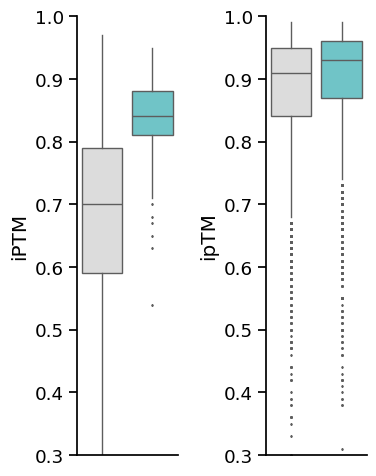

In [34]:
plot_df_sm = pd.concat([
    existing_references_df[existing_references_df['ligand'].isin(small_molecule_annotated_true['small_molecule'].unique())]['iptm'],
    small_molecule_annotated_true[['iptm']],
])
plot_df_sm['model'] = ['Reference'] * (len(plot_df_sm) - len(small_molecule_annotated_true)) + ['ATOMICA-Ligand'] * len(small_molecule_annotated_true)

plot_df_mi = pd.concat([
    existing_references_df[existing_references_df['ligand'].isin(metal_ion_annotated_true['metal_ion'].unique())]['iptm'],
    metal_ion_annotated_true[['iptm']],
])
plot_df_mi['model'] = ['Reference'] * (len(plot_df_mi) - len(metal_ion_annotated_true)) + ['ATOMICA-Ligand'] * len(metal_ion_annotated_true)

plt.figure(figsize=(4,5))

sns.set_context("notebook", font_scale=1.2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4,5))

sns.boxplot(
    x='model',
    y='iptm',
    data=plot_df_sm,
    palette=['#DCDCDC', '#62D1D5'],
    ax = ax1,
    linewidth=1,
    flierprops={'markersize': 1}, 
    showcaps=False
)
ax1.set_ylabel('iPTM')
ax1.set_ylim(0.3, 1)
ax1.set_xlabel('')
ax1.set_xticklabels([])
ax1.set_xticks([])

sns.boxplot(
    x='model',
    y='iptm',
    data=plot_df_mi,
    palette=['#DCDCDC', '#62D1D5'],
    ax = ax2,
    linewidth=1,
    flierprops={'markersize': 1},
    showcaps=False
)
ax2.set_ylabel('ipTM')
ax2.set_ylim(0.3, 1)
ax2.set_xlabel('')
ax2.set_xticklabels([])
ax2.set_xticks([])

sns.despine(ax=ax1)
sns.despine(ax=ax2)
plt.tight_layout()

print("Num small molecule binding sites annotated:", len(small_molecule_annotated_true))
print("Num metal ion binding sites annotated:", len(metal_ion_annotated_true))

plt.savefig('iptm_boxplot.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

In [35]:
print("Num metal ion binding sites annotated:", len(metal_ion_annotated_true['id'].unique()))
print("Num small molecule binding sites annotated:", len(small_molecule_annotated_true['id'].unique()))

Num metal ion binding sites annotated: 2565
Num small molecule binding sites annotated: 81


In [36]:
from scipy.stats import ks_2samp

print("Small Molecule iPTM")
print(ks_2samp(plot_df_sm[plot_df_sm['model']=='Reference']['iptm'], plot_df_sm[plot_df_sm['model']=='ATOMICA-Ligand']['iptm']))
print("Metal Ion iPTM")
print(ks_2samp(plot_df_mi[plot_df_mi['model']=='Reference']['iptm'], plot_df_mi[plot_df_mi['model']=='ATOMICA-Ligand']['iptm']))

Small Molecule iPTM
KstestResult(statistic=0.5411764705882353, pvalue=9.185150207787391e-12, statistic_location=0.8, statistic_sign=1)
Metal Ion iPTM
KstestResult(statistic=0.1087248322147651, pvalue=9.429797060205117e-16, statistic_location=0.91, statistic_sign=1)


/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='iptm', ylabel='Count'>

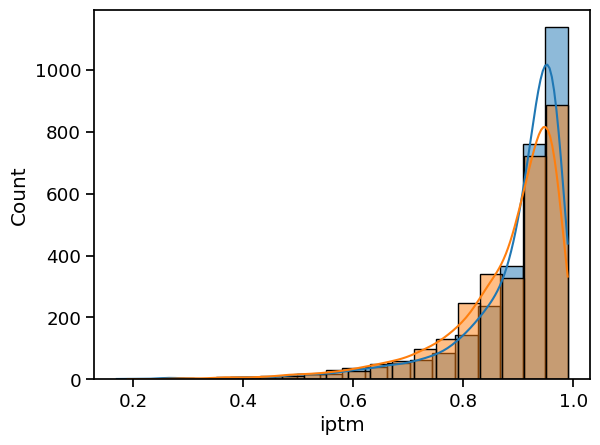

In [37]:
sns.histplot(metal_ion_annotated_true['iptm'], bins=20, kde=True)
sns.histplot(existing_references_df[existing_references_df['ligand'].isin(metal_ion_annotated_true['metal_ion'].unique())]['iptm'], bins=20, kde=True)

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='iptm', ylabel='Count'>

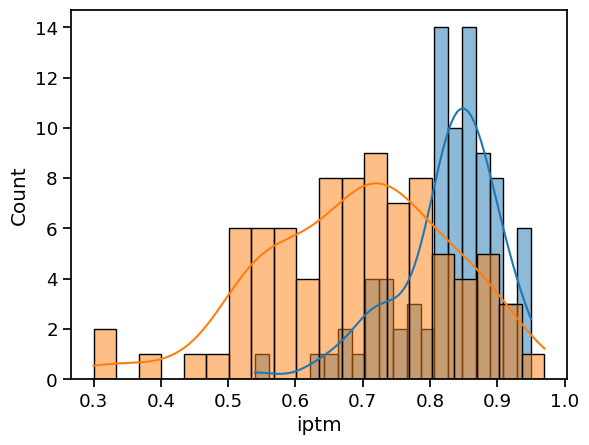

In [38]:
sns.histplot(small_molecule_annotated_true['iptm'], bins=20, kde=True)
sns.histplot(existing_references_df[existing_references_df['ligand'].isin(small_molecule_annotated_true['small_molecule'].unique())]['iptm'], bins=20, kde=True)

# Annotate binding sites

In [39]:
cluster_assignments = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/1-AFDBClusters-entryId_repId_taxId.tsv.gz', compression='gzip', sep='\t', names=['memberID', 'repId', 'taxId'])
taxonomy_df = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/taxonomy_all_2025_01_15.tsv', sep='\t', dtype={'Taxon Id':int, 'Common name': str, 'Scientific name': str, 'Lineage': str, 'Links': str})
cluster_assignments = cluster_assignments.merge(taxonomy_df[['Taxon Id', 'Lineage']], left_on='taxId', right_on='Taxon Id')
foldseek_cluster = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/2-repId_isDark_nMem_repLen_avgLen_repPlddt_avgPlddt_LCAtaxId.tsv", sep="\t",
                                names= ["repID", "isDark", "nMem", "repLen", "avgLen", "repPlddt", "avgPlddt", "LCAtaxID"])

In [40]:
cluster_assignments_reps = cluster_assignments[cluster_assignments['memberID'] == cluster_assignments['repId']].drop(columns=['memberID'])
small_molecule_data = foldseek_cluster[foldseek_cluster['repID'].isin(small_molecule_annotated_true['id'].unique())].merge(cluster_assignments_reps, left_on='repID', right_on='repId')
metal_ion_data = foldseek_cluster[foldseek_cluster['repID'].isin(metal_ion_annotated_true['id'].unique())].merge(cluster_assignments_reps, left_on='repID', right_on='repId')
small_molecule_data_annotated = small_molecule_annotated_true.merge(small_molecule_data, left_on='id', right_on='repID', how='outer')
metal_ion_data_annotated = metal_ion_annotated_true.merge(metal_ion_data, left_on='id', right_on='repID', how='outer')

Species analysis

In [41]:
small_molecule_data_annotated['domain'] = small_molecule_data_annotated['Lineage'].apply(lambda x: x.split(",")[1].strip() if not pd.isna(x) else x)
metal_ion_data_annotated['domain'] = metal_ion_data_annotated['Lineage'].apply(lambda x: x.split(",")[1].strip() if not pd.isna(x) else x)
small_molecule_data_annotated['species'] = small_molecule_data_annotated['Lineage'].apply(lambda x: x.split(",")[-1].strip() if not pd.isna(x) else x)
metal_ion_data_annotated['species'] = metal_ion_data_annotated['Lineage'].apply(lambda x: x.split(",")[-1].strip() if not pd.isna(x) else x)

In [42]:
annotated_species = pd.concat([small_molecule_data_annotated[['species', 'domain']], metal_ion_data_annotated[['species', 'domain']]])
annotated_species.dropna(inplace=True)
annotated_species = annotated_species[annotated_species['domain'] != 'unclassified sequences']
annotated_species.drop_duplicates(inplace=True)
print("Number of unique species annotated:", len(annotated_species))
annotated_species.groupby(['domain'])['species'].count()

Number of unique species annotated: 1265


domain
Archaea       115
Bacteria     1051
Eukaryota      99
Name: species, dtype: int64

iPTM scores

In [56]:
small_molecule_data_annotated[small_molecule_data_annotated['small_molecule']=='NAP'][
    ['repID', 'mean', 'std', 'iptm', 'ptm', 'isDark', 'nMem', 'avgLen', 'repPlddt', 'avgPlddt', 'Lineage']
].sort_values(by='iptm', ascending=False)

,repID,mean,std,iptm,ptm,isDark,nMem,avgLen,repPlddt,avgPlddt,Lineage
58,A0A7C6CYQ5,0.069086,0.077765,0.87,0.89,1,5,68.800,93.00,91.3740,"cellular organisms, Bacteria, Terrabacteria gr..."
33,A0A2P9I417,0.067635,0.105537,0.87,0.75,1,4,354.000,91.88,92.7825,NaN
80,R6AU30,0.220946,0.367592,0.76,0.64,1,3,181.667,91.12,92.6633,"cellular organisms, Bacteria, Terrabacteria gr..."
7,A0A142JR74,0.237424,0.397786,0.70,0.85,1,7,159.714,94.88,91.1786,"cellular organisms, Bacteria, Pseudomonadota, ..."
34,A0A2S2DFW0,0.313866,0.520949,0.63,0.70,1,2,138.000,90.31,90.5300,"cellular organisms, Bacteria, Pseudomonadota, ..."
17,A0A1H9WNP9,0.223477,0.340260,0.54,0.70,1,4,130.000,93.44,93.5625,"cellular organisms, Bacteria, Terrabacteria gr..."


In [43]:
small_molecule_data_annotated[small_molecule_data_annotated['small_molecule']=='HEM'][
    ['repID', 'mean', 'std', 'iptm', 'ptm', 'isDark', 'nMem', 'avgLen', 'repPlddt', 'avgPlddt', 'Lineage']
].sort_values(by='iptm', ascending=False)

# small_molecule_data_annotated[small_molecule_data_annotated['small_molecule']=='HEM'][
#     ['repID', 'mean', 'std', 'iptm', 'ptm', 'isDark', 'nMem', 'avgLen', 'repPlddt', 'avgPlddt', 'Lineage']
# ].sort_values(by='iptm', ascending=False).to_csv('HEM_annotated.csv', index=False)

,repID,mean,std,iptm,ptm,isDark,nMem,avgLen,repPlddt,avgPlddt,Lineage
82,V5BF69,0.663142,0.571876,0.94,0.86,1,10,606.500,89.31,90.2180,"cellular organisms, Bacteria, Pseudomonadota, ..."
53,A0A6B2YTG2,0.756665,0.393772,0.93,0.90,1,134,265.806,94.12,94.1024,"cellular organisms, Bacteria, Terrabacteria gr..."
5,A0A0Q8RCH2,0.974794,0.033481,0.93,0.87,1,4,221.750,90.75,90.8125,"cellular organisms, Bacteria, Pseudomonadota, ..."
6,A0A136KY61,0.334532,0.563261,0.91,0.92,1,11,216.000,90.19,91.0809,"cellular organisms, Bacteria, Terrabacteria gr..."
69,A0A7W7ZIE7,0.452484,0.446385,0.90,0.86,1,3,280.333,90.31,90.7500,"cellular organisms, Bacteria, Acidobacteriota,..."
38,A0A2V7V2X7,0.228624,0.344068,0.90,0.87,1,31,163.839,92.94,92.1694,"cellular organisms, Bacteria, Acidobacteriota,..."
68,A0A7W1B5T5,0.311670,0.521865,0.89,0.86,1,4,114.750,92.12,92.5475,"cellular organisms, Bacteria, Myxococcota, Myx..."
22,A0A1X9N5L9,0.159869,0.267036,0.89,0.89,1,26,334.692,90.62,93.6681,"cellular organisms, Bacteria, Pseudomonadota, ..."
46,A0A4P5TA35,0.249504,0.405607,0.89,0.90,1,2,157.000,93.62,93.7500,"cellular organisms, Bacteria, FCB group, Bacte..."
76,H2CF85,0.711514,0.493575,0.89,0.90,1,2,140.000,92.81,92.1850,"cellular organisms, Bacteria, Spirochaetota, S..."


In [44]:
metal_ion_data_annotated[metal_ion_data_annotated['metal_ion']=='CA'][
    ['repID', 'mean', 'std', 'iptm', 'isDark', 'nMem', 'avgLen', 'repPlddt', 'avgPlddt', 'Lineage']
].sort_values(by='iptm', ascending=False).head(50)

,repID,mean,std,iptm,isDark,nMem,avgLen,repPlddt,avgPlddt,Lineage
2262,A0A7K3IUI2,0.930542,0.001382,0.98,1,20,601.800,92.44,92.7010,"cellular organisms, Bacteria, FCB group, Bacte..."
775,A0A2C8F3B4,0.657109,0.463238,0.98,1,3,290.333,95.75,94.6667,"cellular organisms, Bacteria, Thermodesulfobac..."
1376,A0A3E0PPM6,0.847757,0.088125,0.98,1,11,417.182,95.81,94.1364,"cellular organisms, Bacteria, PVC group, Planc..."
42,A0A0C3IL85,0.591796,0.358852,0.98,1,8,371.125,95.00,93.1325,"cellular organisms, Bacteria, Pseudomonadota, ..."
924,A0A2M7A505,0.879154,0.066428,0.98,1,3,356.667,92.12,90.0200,"cellular organisms, Bacteria, Terrabacteria gr..."
1803,A0A554MPP7,0.880427,0.051168,0.98,1,12,331.000,82.44,91.4375,"cellular organisms, Bacteria, Bacteria incerta..."
923,A0A2L2WUE4,0.931480,0.002250,0.98,1,3,316.000,91.38,90.4600,"cellular organisms, Bacteria, FCB group, Bacte..."
1308,A0A3B0XBT7,0.928970,0.005294,0.97,1,6,199.500,92.88,90.8983,"unclassified entries, unclassified sequences, ..."
1677,A0A512M9L4,0.931454,0.002474,0.97,1,7,191.000,93.31,92.4200,"cellular organisms, Bacteria, PVC group, Verru..."
1669,A0A4Z0MGM6,0.928058,0.001705,0.97,1,8,211.375,93.12,90.4825,"cellular organisms, Bacteria, FCB group, Bacte..."


In [45]:
metal_ion_data_annotated[metal_ion_data_annotated['metal_ion']=='MG'][
    ['repID', 'mean', 'std', 'iptm', 'isDark', 'nMem', 'avgLen', 'repPlddt', 'avgPlddt', 'Lineage']
].sort_values(by='iptm', ascending=False).head(50)

,repID,mean,std,iptm,isDark,nMem,avgLen,repPlddt,avgPlddt,Lineage
1176,A0A328ECM6,0.618624,0.510881,0.98,1,2,314.500,90.44,91.2500,"cellular organisms, Bacteria, Bacteria incerta..."
2796,J9GYR6,0.649250,0.259612,0.97,1,6,466.000,94.62,92.1133,"unclassified entries, unclassified sequences, ..."
200,A0A0R0B241,0.649584,0.098121,0.97,1,4,191.000,92.56,91.7800,"cellular organisms, Bacteria, Pseudomonadota, ..."
1741,A0A534SAT4,0.764542,0.241923,0.97,1,2,327.500,91.38,91.6900,"cellular organisms, Bacteria, Myxococcota, Myx..."
1698,A0A520B513,0.920281,0.048293,0.97,1,2,293.500,93.19,90.5000,"cellular organisms, Bacteria, Pseudomonadota, ..."
1678,A0A512M9L4,0.862073,0.094473,0.97,1,7,191.000,93.31,92.4200,"cellular organisms, Bacteria, PVC group, Verru..."
1972,A0A6A8A8B6,0.872897,0.075158,0.96,1,3,269.667,94.00,92.6867,"cellular organisms, Bacteria, Pseudomonadota, ..."
1830,A0A5C4MA15,0.916056,0.019926,0.96,1,6,356.500,95.31,94.3533,"cellular organisms, Bacteria, Terrabacteria gr..."
1299,A0A3A9K827,0.889783,0.101846,0.96,1,15,235.667,94.50,93.5000,"cellular organisms, Bacteria, Terrabacteria gr..."
495,A0A1I6X118,0.760384,0.220207,0.96,1,4,246.000,94.12,92.9500,"cellular organisms, Bacteria, Terrabacteria gr..."


In [46]:
metal_ion_data_annotated[metal_ion_data_annotated['metal_ion']=='ZN'][
    ['repID', 'mean', 'std', 'iptm', 'isDark', 'nMem', 'avgLen', 'repPlddt', 'avgPlddt', 'Lineage']
].sort_values(by='iptm', ascending=False).head(50)

,repID,mean,std,iptm,isDark,nMem,avgLen,repPlddt,avgPlddt,Lineage
1999,A0A6C0E0P4,0.932996,0.021201,0.99,1,25,402.600,92.50,91.1500,"unclassified entries, unclassified sequences, ..."
2491,A0A7Y4VG56,0.934273,0.022436,0.99,1,18,504.333,88.44,91.0344,"cellular organisms, Bacteria, FCB group, Bacte..."
220,A0A0T5Z5Z2,0.935145,0.022646,0.99,1,3,390.333,95.25,92.1433,"cellular organisms, Bacteria, Pseudomonadota, ..."
799,A0A2D6TT51,0.912935,0.006040,0.98,1,5,306.200,90.94,91.6740,"cellular organisms, Bacteria, Pseudomonadota, ..."
2179,A0A7C5W3F3,0.806406,0.135645,0.98,1,42,212.119,80.50,90.4981,"cellular organisms, Bacteria, PVC group, Planc..."
2158,A0A7C3LKA2,0.934672,0.021851,0.98,1,2,260.500,92.56,92.8400,"cellular organisms, Bacteria, Terrabacteria gr..."
2169,A0A7C4VJI4,0.934640,0.024721,0.98,1,2,292.000,93.88,92.5000,"cellular organisms, Archaea, TACK group, Candi..."
158,A0A0M2LL74,0.936229,0.022067,0.98,1,9,228.667,92.06,90.5767,"cellular organisms, Bacteria, Terrabacteria gr..."
2253,A0A7J5TS81,0.933176,0.019476,0.98,1,2,282.500,92.25,91.5300,"cellular organisms, Bacteria, FCB group, Bacte..."
1380,A0A3E5F642,0.936233,0.021944,0.98,1,2,286.000,92.69,92.3450,"cellular organisms, Bacteria, FCB group, Bacte..."


In [47]:
metal_ion_data_annotated[metal_ion_data_annotated['metal_ion']=='MN'][
    ['repID', 'mean', 'std', 'iptm', 'isDark', 'nMem', 'avgLen', 'repPlddt', 'avgPlddt', 'Lineage']
].sort_values(by='iptm', ascending=False).head(50)

,repID,mean,std,iptm,isDark,nMem,avgLen,repPlddt,avgPlddt,Lineage
703,A0A238D4T2,0.702228,0.101832,0.98,1,31,238.1610,88.50,92.3506,"cellular organisms, Bacteria, Pseudomonadota, ..."
496,A0A1I6X118,0.378279,0.405014,0.97,1,4,246.0000,94.12,92.9500,"cellular organisms, Bacteria, Terrabacteria gr..."
560,A0A1Q7VGP7,0.915182,0.050480,0.97,1,2,187.5000,87.88,91.0950,"cellular organisms, Bacteria, Pseudomonadota, ..."
1973,A0A6A8A8B6,0.488883,0.452949,0.97,1,3,269.6670,94.00,92.6867,"cellular organisms, Bacteria, Pseudomonadota, ..."
835,A0A2E3NEX7,0.658092,0.506151,0.96,1,2,157.5000,95.38,94.8800,"cellular organisms, Bacteria, Myxococcota, Myx..."
1717,A0A523M2C2,0.498863,0.386372,0.96,1,14,124.1430,94.00,94.8314,"cellular organisms, Bacteria, Pseudomonadota, ..."
1975,A0A6A9QTF9,0.699621,0.447962,0.96,1,12,136.1670,95.06,93.4325,"cellular organisms, Archaea, TACK group, Therm..."
2009,A0A6C0IJD8,0.648397,0.447533,0.96,1,6,133.5000,91.88,90.2100,"unclassified entries, unclassified sequences, ..."
2903,S2E9B6,0.529231,0.470027,0.96,1,5,122.8000,94.00,92.6760,"cellular organisms, Bacteria, FCB group, Bacte..."
452,A0A1H7N070,0.703185,0.265508,0.95,1,5,160.6000,90.88,90.9760,"cellular organisms, Archaea, Euryarchaeota, St..."


In [48]:
metal_ion_data_annotated[metal_ion_data_annotated['metal_ion']=='FE'][
    ['repID', 'mean', 'std', 'iptm', 'isDark', 'nMem', 'avgLen', 'repPlddt', 'avgPlddt', 'Lineage']
].sort_values(by='iptm', ascending=False).head(50)

,repID,mean,std,iptm,isDark,nMem,avgLen,repPlddt,avgPlddt,Lineage
1883,A0A5N8YIC6,0.403302,0.480759,0.99,1,2,388.500,89.94,91.7800,"cellular organisms, Bacteria, Terrabacteria gr..."
1998,A0A6C0E0P4,0.878660,0.119912,0.99,1,25,402.600,92.50,91.1500,"unclassified entries, unclassified sequences, ..."
2490,A0A7Y4VG56,0.972393,0.017471,0.99,1,18,504.333,88.44,91.0344,"cellular organisms, Bacteria, FCB group, Bacte..."
2328,A0A7V2HWX7,0.768945,0.331649,0.98,1,13,293.077,78.81,90.1046,"cellular organisms, Bacteria, Bacteria incerta..."
753,A0A292SVL5,0.695062,0.472403,0.98,1,7,273.857,91.69,92.1086,"cellular organisms, Bacteria, Terrabacteria gr..."
786,A0A2D5VXX0,0.655100,0.545741,0.98,1,12,327.167,91.25,90.9175,"cellular organisms, Bacteria, PVC group, Verru..."
702,A0A238D4T2,0.902836,0.050795,0.98,1,31,238.161,88.50,92.3506,"cellular organisms, Bacteria, Pseudomonadota, ..."
1731,A0A532D0P4,0.936004,0.019759,0.98,1,9,234.556,92.31,93.5756,"cellular organisms, Bacteria, Nitrospirota, Ni..."
1607,A0A4R4ER56,0.384469,0.511864,0.98,1,35,334.743,87.50,91.6954,"cellular organisms, Bacteria, Terrabacteria gr..."
1627,A0A4S2N686,0.344056,0.527572,0.98,1,5,244.400,92.38,90.0500,"cellular organisms, Eukaryota, Opisthokonta, F..."


In [49]:
small_molecule_data_annotated[small_molecule_data_annotated['id']=='A0A6B2YTG2']['results_path'].values[0]

'/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/atomica_ligand/analyses/updated_model/outputs/old/a0a6b2ytg2_hem'

### clusters for further annotation

In [50]:
cluster_reps = {
    # "A0A6B2YTG2": "HEM",
    # "A0A496MS18": "CA",
    # "A0A524EDF0": "MG",
    # "A0A496MS18": "MG",
    # "A0A238D4T2": "ZN",
    # "W8VVQ2": "ZN",
    # "A0A238D4T2": "MN",
    # "A0A351MV06": "FE",
    # "A0A6C0E0P4": "FE",
    # "A0A7Y4VG56": "FE",
    # "A0A0M0BG38": "MG",
    # "A0A2U9ILP6": "MG",
    # "A0A6B2YTG2": "CU",
    # "A0A2V8JCM5": "HEM",
    # "A0A0K3BHV0": "HEM",
    "A0A2T0LHX9": "HEM",
}

members = cluster_assignments[cluster_assignments['repId'].isin(cluster_reps.keys())]['memberID'].unique()
members_to_rep_id = cluster_assignments[cluster_assignments['memberID'].isin(members)][['memberID', 'repId']].set_index('memberID').to_dict()['repId']
len(members)

6

In [51]:
# # for downloading files
# dark_cluster_dir = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/dark_clusters"
# files_per_download = len(members)//4 + 1

# for i in range(4):
#     with open(f"{dark_cluster_dir}/dark_cluster_{i+12}.txt", 'w') as f:
#         for member in members[i*files_per_download:(i+1)*files_per_download]:
#             f.write(f"{member}\n")

In [52]:
# # for writing pesto files to run 
# pesto_dir = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt_pesto"
# files_per_download = len(members)//12 + 1

# for i in range(12):
#     with open(f"{pesto_dir}/pesto_{i+27}.txt", 'w') as f:
#         for member in members[i*files_per_download:(i+1)*files_per_download]:
#             f.write(f"{member}\n")

In [53]:
# for running AF3
dark_cluster_dir = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/dark_clusters"
member_fastas = {}
for member in tqdm(members, total=len(members)):
    pdb_file = os.path.join(dark_cluster_dir, f"{member}.pdb")
    member_fastas[member] = pdb_to_fasta(pdb_file)[f"{member}_A"]

files_per_run = len(members)//6 + 1
print("files per run:", files_per_run)
start_idx = max([int(fname) for fname in os.listdir("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/dark_proteome_clusters/inputs/") if fname.isdigit()]) + 1
total_written = 0
for member in tqdm(members, total=len(members)):
    os.makedirs(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/dark_proteome_clusters/inputs/{total_written//files_per_run + start_idx}", exist_ok=True)
    fasta_str = member_fastas[member]
    rep_id = cluster_assignments[cluster_assignments['memberID'] == member]['repId'].values[0]
    write_AF3_json(member, fasta_str, cluster_reps[members_to_rep_id[member]], f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/dark_proteome_clusters/inputs/{total_written//files_per_run + start_idx}/{member}_{cluster_reps[members_to_rep_id[member]]}.json")
    total_written += 1

  0%|          | 0/6 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: '/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/dark_clusters/A0A1V5GGT6.pdb'

In [ ]:
output = glob("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/dark_proteome_clusters/outputs/**/**/*_summary_confidences.json")
dark_clusters_output = []
for fname in output:
    member = os.path.basename(fname).split("_")[0].upper()
    ligand = os.path.basename(fname).split("_")[1].upper()
    rep_id = members_to_rep_id[member]
    dark_clusters_output.append({
        'repID': rep_id,
        'memberID': member,
        'ligand': ligand,
        'results_path': fname,
        'iPTM': get_iptm(fname),
    })
dark_clusters_output = pd.DataFrame(dark_clusters_output)

: 

: 

In [ ]:
dark_clusters_output.groupby(['repID', 'ligand'])['iPTM'].agg(['mean', 'std', 'count'])

,,mean,std,count
repID,ligand,,,
A0A0M0BG38,MG,0.909556,0.029073,45
A0A238D4T2,MN,0.976452,0.004864,31
A0A2U9ILP6,MG,0.911739,0.014664,23
A0A351MV06,FE,0.978273,0.009173,110
A0A496MS18,MG,0.930296,0.025412,169
A0A524EDF0,MG,0.926681,0.022011,226
A0A6B2YTG2,HEM,0.885448,0.036883,134
A0A6C0E0P4,FE,0.984000,0.005000,25
A0A7Y4VG56,FE,0.957778,0.053309,18


: 

: 

In [ ]:
# pesto_ids = list(set(np.concatenate([metal_ion_data_annotated['id'].unique(), small_molecule_data_annotated['id'].unique()])))
# jobs_per_file = len(pesto_ids)//4 + 1
# for i in range(len(pesto_ids)//jobs_per_file + 1):
#     with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt_pesto/pesto_{i+start_idx}.txt", 'w') as f:
#         for pesto_id in pesto_ids[i*jobs_per_file:(i+1)*jobs_per_file]:
#             f.write(f"AF-{pesto_id}-F1-model_v4\n")
#         print("HI")

: 

: 